# Late Fusion (Dung hợp Cấp Quyết Định)

- **Cấu trúc**: MLP dành riêng cho Tabular và ResNet50 dành riêng cho Image.
- **Dung hợp**: `(Xác suất Bảng + Xác suất Ảnh) / 2`.

In [1]:
import sys; sys.path.append('..')
import torch
import torch.nn as nn
import torch.nn.functional as F
from _shared_fusion_env import get_dataloaders, get_device
from torchvision.models import resnet50, ResNet50_Weights
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay

device = get_device()
train_loader, test_loader, weights, tab_dim = get_dataloaders(batch_size=32)
weights = weights.to(device)
print(f"Device: {device} | Tabular Dim: {tab_dim}")

/Users/hhh/workspace/school/PBL7/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/hhh/workspace/school/PBL7/venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: mps | Tabular Dim: 58


In [2]:
class LateFusionModel(nn.Module):
    def __init__(self, tab_dim, num_classes=6):
        super().__init__()
        self.img_net = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.img_net.fc = nn.Linear(self.img_net.fc.in_features, num_classes)
        
        self.tab_net = nn.Sequential(
            nn.Linear(tab_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
        
    def forward(self, img, tab):
        out_img = self.img_net(img)
        out_tab = self.tab_net(tab)
        # Nối lại bằng trung bình Softmax (Bỏ phiếu cấp cao)
        prob_img = F.softmax(out_img, dim=1)
        prob_tab = F.softmax(out_tab, dim=1)
        return (prob_img + prob_tab) / 2.0  # Trả về Vector xác suất Trung bình

In [3]:
model = LateFusionModel(tab_dim).to(device)
criterion = nn.NLLLoss(weight=weights) # Vì output đã qua softmax dải 0-1, NLL chạy với log là chuẩn nhất
criterion_raw = nn.CrossEntropyLoss(weight=weights)

E1, E2 = 10, 40
# Giai đoạn 1: Khóa thân mạng Ảnh
for param in model.img_net.parameters(): param.requires_grad = False
for param in model.img_net.fc.parameters(): param.requires_grad = True
opt1 = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

print("=== Phase 1: Feature Extractor Frozen (10 Epochs) ===")
for ep in range(E1):
    model.train()
    running_loss = 0.0
    for imgs, tabs, lbls in tqdm(train_loader, leave=False):
        imgs, tabs, lbls = imgs.to(device), tabs.to(device), lbls.to(device)
        opt1.zero_grad()
        out = model(imgs, tabs)
        loss = criterion_raw(torch.log(out + 1e-8), lbls) # CrossEntropy nhận giá trị thuần hoặc log
        loss.backward()
        opt1.step()
        running_loss += loss.item()
    print(f"Epoch {ep+1} | Loss: {running_loss/len(train_loader):.4f}")

# Giai đoạn 2: Unfreeze
for param in model.parameters(): param.requires_grad = True
opt2 = torch.optim.Adam(model.parameters(), lr=1e-5)

print("\n=== Phase 2: End-to-end Fine-tuning (40 Epochs) ===")
for ep in range(E2):
    model.train()
    running_loss = 0.0
    for imgs, tabs, lbls in tqdm(train_loader, leave=False):
        imgs, tabs, lbls = imgs.to(device), tabs.to(device), lbls.to(device)
        opt2.zero_grad()
        out = model(imgs, tabs)
        loss = criterion_raw(torch.log(out + 1e-8), lbls)
        loss.backward()
        opt2.step()
        running_loss += loss.item()
    if (ep+1) % 5 == 0: print(f"Epoch {ep+E1+1} | Loss: {running_loss/len(train_loader):.4f}")

=== Phase 1: Feature Extractor Frozen (10 Epochs) ===


Epoch 1 | Loss: 1.2584


Epoch 2 | Loss: 0.8622


Epoch 3 | Loss: 0.7012


Epoch 4 | Loss: 0.6323


...

Epoch 30 | Loss: 0.1458


Epoch 35 | Loss: 0.1460


Epoch 40 | Loss: 0.1427


Epoch 45 | Loss: 0.1388


Epoch 50 | Loss: 0.1367


100%|██████████| 15/15 [00:18<00:00,  1.21s/it]



🏆 F1-Macro LATE FUSION: 0.7034


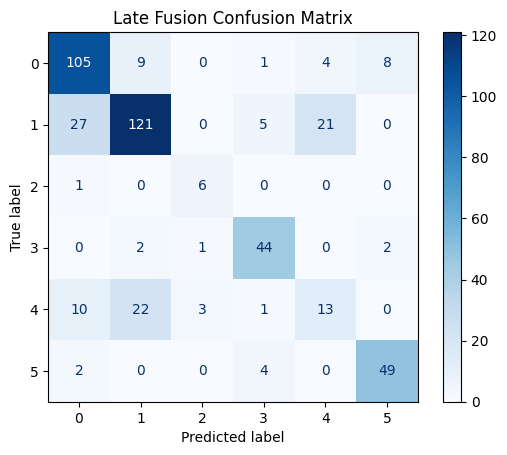

In [4]:
model.eval()
preds, trues = [], []
with torch.no_grad():
    for imgs, tabs, lbls in tqdm(test_loader):
        out = model(imgs.to(device), tabs.to(device))
        _, y_hat = torch.max(out, 1)
        preds.extend(y_hat.cpu().numpy())
        trues.extend(lbls.numpy())

f1 = f1_score(trues, preds, average='macro')
print(f"\n🏆 F1-Macro LATE FUSION: {f1:.4f}")
disp = ConfusionMatrixDisplay(confusion_matrix(trues, preds))
disp.plot(cmap='Blues')
plt.title('Late Fusion Confusion Matrix')
plt.show()

## Lưu Mô hình (Model Checkpoint)
Bảo toàn Trọng số học được (Weights) để phục vụ cho Test độc lập hoặc Triển khai Web App/Mobile sau này mà không cần Train lại.

In [5]:
import os
os.makedirs('../../saved_models', exist_ok=True)
save_path = '../../saved_models/late_fusion.pth'
torch.save(model.state_dict(), save_path)
print(f"✅ Đã lưu trọng số mô hình tại: {save_path}")

✅ Đã lưu trọng số mô hình tại: ../../saved_models/late_fusion.pth
